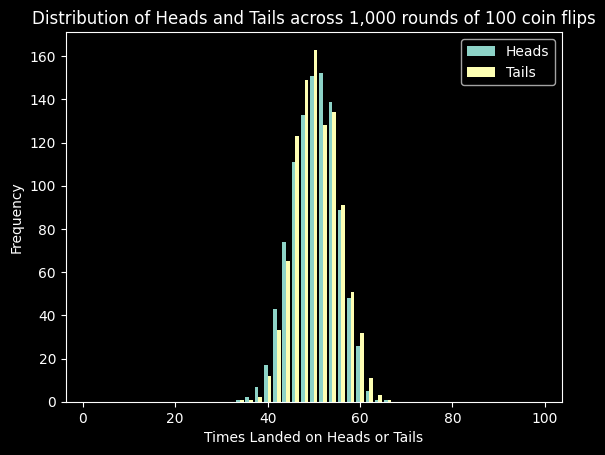

In [ ]:
# Coin toss simultor with the results displayed
# in a a distribution histogram

import random
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor

# Define function for parallel processing of
# simulated coin flips for a distribution

def flip_rounds(flips):
        heads = 0
        tails = 0
        for _ in range(flips):
            coin_flip = random.randint(1, 2)
            if coin_flip == 1:
                heads += 1
            else:
                tails += 1
        return(heads, tails)

rounds = 1_000
flips = 100

with ProcessPoolExecutor(max_workers=30) as executor:
    all_results = list(executor.map(flip_rounds, [flips]*rounds))

'''
all_results = []
rounds = 0

for _ in range(5000000):
    heads = 0
    tails = 0
    flips = 0

    while flips < 1000:
        coin_flip = random.randint(1, 2)
        flips += 1
        if coin_flip == 1:
            heads += 1
        else:
            tails += 1

    rounds += 1
    all_results.append((heads, tails))

all_results'''


# Seperate Heads and Tails so we can display them in
# a histogram
heads_list = [result[0] for result in all_results]
tails_list = [result[1] for result in all_results]

plt.hist([heads_list, tails_list], bins=range(
    1, 101, 2), label=['Heads', 'Tails'])
plt.xlabel('Times Landed on Heads or Tails')
plt.ylabel('Frequency')
plt.title(
    f'Distribution of Heads and Tails across {rounds:,} rounds of {flips} coin flips')
plt.legend()
plt.show()